In [44]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

import pandas as pd

# Воспроизводимость
RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

set_seed()
# Устройство
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


Данные и DataLoader

In [45]:
from torch.utils.data import DataLoader, TensorDataset, random_split

@dataclass
class DataConfig:
    dataset_name: str = "EMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10" | "DIGITS_FALLBACK"
    data_dir: str = "./data"
    batch_size: int = 128
    val_fraction: float = 0.2
    num_workers: int = 0
    fast_mode: bool = False
    max_train_samples: int = 12000   # используется только в fast_mode для больших датасетов
    max_val_samples: int = 2000
    max_test_samples: int = 3000

def _try_load_torchvision_dataset(cfg: DataConfig):
    """Пытаемся загрузить torchvision-датасет.
    Возвращаем: (train_dataset, test_dataset, input_dim, num_classes, info_str)
    """
    import torchvision
    from torchvision import datasets, transforms

    name = cfg.dataset_name.upper().strip()

    if name in {"EMNIST"}:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    if name == "EMNIST":
        train_ds = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=True, download=True, transform=transform)
        test_ds  = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 47, "torchvision.EMNIST(split='balanced') (28x28, 47 классов)"

    if name == "CIFAR10":
        transform_cifar = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
        ])
        train_ds = datasets.CIFAR10(root=cfg.data_dir, train=True, download=True, transform=transform_cifar)
        test_ds  = datasets.CIFAR10(root=cfg.data_dir, train=False, download=True, transform=transform_cifar)
        return train_ds, test_ds, 32 * 32 * 3, 10, "torchvision.CIFAR10 (32x32x3, 10 классов)"

    raise ValueError(f"Unknown torchvision dataset_name={cfg.dataset_name!r}")

def load_data(cfg: DataConfig):
    train_ds, test_ds, input_dim, num_classes, info = _try_load_torchvision_dataset(cfg)

    val_size = int(len(train_ds) * cfg.val_fraction)
    train_size = len(train_ds) - val_size

    generator = torch.Generator().manual_seed(RANDOM_STATE)
    train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

    def maybe_subsample(ds, max_n: int):
        if not cfg.fast_mode:
            return ds
        if len(ds) <= max_n:
            return ds
        idx = torch.randperm(len(ds), generator=generator)[:max_n]
        return torch.utils.data.Subset(ds, idx.tolist())

    train_split = maybe_subsample(train_split, cfg.max_train_samples)
    val_split   = maybe_subsample(val_split,   cfg.max_val_samples)
    test_ds     = maybe_subsample(test_ds,     cfg.max_test_samples)

    train_loader = DataLoader(train_split, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_split,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader, input_dim, num_classes, info

data_cfg = DataConfig(dataset_name="EMNIST", fast_mode=True)
train_loader, val_loader, test_loader, INPUT_DIM, NUM_CLASSES, DATA_INFO = load_data(data_cfg)

print("Dataset:", DATA_INFO)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))
print("INPUT_DIM:", INPUT_DIM, "| NUM_CLASSES:", NUM_CLASSES)

Dataset: torchvision.EMNIST(split='balanced') (28x28, 47 классов)
Train batches: 94 | Val batches: 16 | Test batches: 24
INPUT_DIM: 784 | NUM_CLASSES: 47


In [46]:
def unpack_batch(batch):
    x, y = batch
    return x, y

batch = next(iter(train_loader))
x, y = unpack_batch(batch)

print("x:", type(x), x.shape, x.dtype)
print("y:", type(y), y.shape, y.dtype)

# Приведем x к виду (batch, input_dim) – нам нужен MLP
if x.dim() > 2:
    x_flat = x.view(x.size(0), -1)
else:
    x_flat = x


print("batch_size:", DataConfig.batch_size)
print("x_flat:", x_flat.shape)
print("min x:", x.min())
print("max x:", x.max())
print("min y:", y.min())
print("max y:", y.max())

x: <class 'torch.Tensor'> torch.Size([128, 1, 28, 28]) torch.float32
y: <class 'torch.Tensor'> torch.Size([128]) torch.int64
batch_size: 128
x_flat: torch.Size([128, 784])
min x: tensor(-1.)
max x: tensor(1.)
min y: tensor(0)
max y: tensor(46)


In [47]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 64),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                  layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [48]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)



def fit(model, train_loader, val_loader, optimizer, criterion, early_stopping=None, epochs=20, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак слишком большого LR. Останавливаем эксперимент.")
            break

    return history


def plot_history(hist, title=""):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

Epoch 01/20 | train loss 2.6709, acc 0.311 | val loss 1.7618, acc 0.503 | 3.0s
Epoch 02/20 | train loss 1.5345, acc 0.566 | val loss 1.3969, acc 0.587 | 2.9s
Epoch 03/20 | train loss 1.2975, acc 0.624 | val loss 1.2716, acc 0.625 | 2.9s
Epoch 04/20 | train loss 1.1591, acc 0.662 | val loss 1.1814, acc 0.653 | 2.9s
Epoch 05/20 | train loss 1.0516, acc 0.690 | val loss 1.1052, acc 0.670 | 2.9s
Epoch 06/20 | train loss 0.9577, acc 0.713 | val loss 1.0472, acc 0.676 | 3.6s
Epoch 07/20 | train loss 0.8808, acc 0.733 | val loss 0.9791, acc 0.706 | 2.9s
Epoch 08/20 | train loss 0.8129, acc 0.751 | val loss 0.9410, acc 0.716 | 3.0s
Epoch 09/20 | train loss 0.7620, acc 0.763 | val loss 0.9032, acc 0.722 | 3.2s
Epoch 10/20 | train loss 0.7040, acc 0.780 | val loss 0.8851, acc 0.728 | 3.1s
Epoch 11/20 | train loss 0.6675, acc 0.789 | val loss 0.8857, acc 0.722 | 3.1s
Epoch 12/20 | train loss 0.6212, acc 0.805 | val loss 0.8540, acc 0.734 | 3.1s
Epoch 13/20 | train loss 0.5842, acc 0.814 | val los

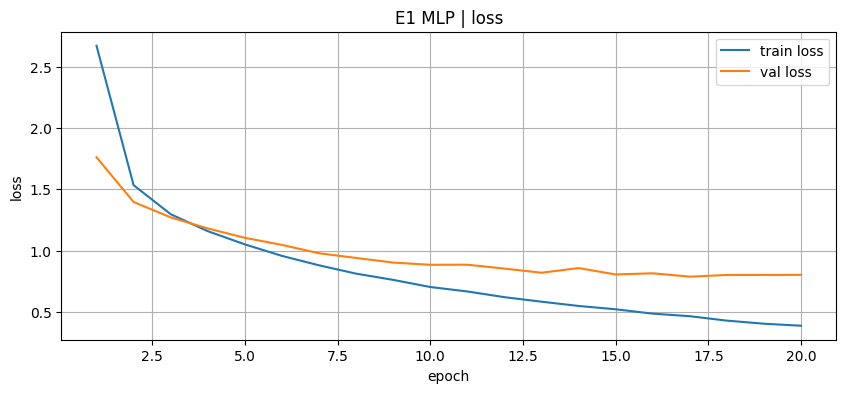

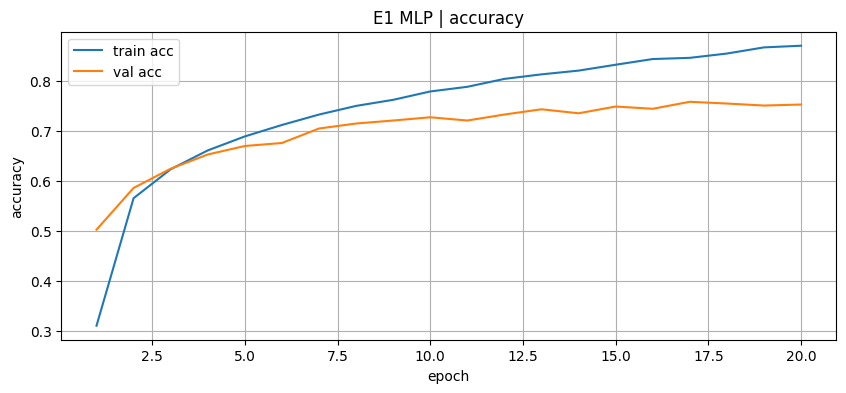

In [49]:
set_seed()
E1 = MLP(hidden_dims=(256, 64), dropout_p=0.0, use_batchnorm=False).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(E1.parameters(), lr=1e-3)

history_E1 = fit(
    E1, train_loader, val_loader,
    optimizer, criterion,
    epochs=20,
    early_stopping=None
)

plot_history(history_E1, title="E1 MLP")

Epoch 01/20 | train loss 2.9740, acc 0.218 | val loss 1.9006, acc 0.483 | 9.1s
Epoch 02/20 | train loss 1.9098, acc 0.452 | val loss 1.4531, acc 0.590 | 8.9s
Epoch 03/20 | train loss 1.5821, acc 0.541 | val loss 1.2510, acc 0.636 | 9.0s
Epoch 04/20 | train loss 1.4035, acc 0.585 | val loss 1.1422, acc 0.652 | 9.8s
Epoch 05/20 | train loss 1.2992, acc 0.614 | val loss 1.0738, acc 0.683 | 9.3s
Epoch 06/20 | train loss 1.2031, acc 0.636 | val loss 1.0404, acc 0.694 | 9.4s
Epoch 07/20 | train loss 1.1356, acc 0.654 | val loss 0.9741, acc 0.701 | 9.1s
Epoch 08/20 | train loss 1.0693, acc 0.677 | val loss 0.9248, acc 0.720 | 9.1s
Epoch 09/20 | train loss 1.0077, acc 0.683 | val loss 0.9014, acc 0.731 | 9.5s
Epoch 10/20 | train loss 0.9703, acc 0.700 | val loss 0.8587, acc 0.733 | 9.8s
Epoch 11/20 | train loss 0.9336, acc 0.704 | val loss 0.8499, acc 0.740 | 9.0s
Epoch 12/20 | train loss 0.9050, acc 0.715 | val loss 0.8104, acc 0.745 | 7.4s
Epoch 13/20 | train loss 0.8705, acc 0.726 | val los

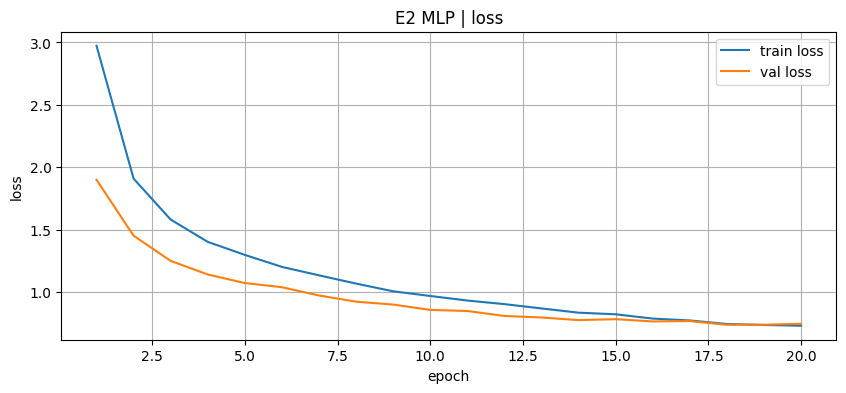

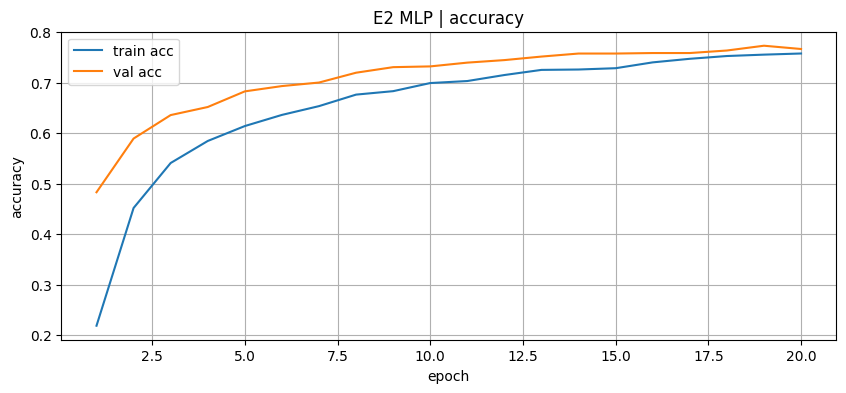

In [50]:
set_seed()
E2 = MLP(hidden_dims=(256, 64), dropout_p=0.2, use_batchnorm=False).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(E2.parameters(), lr=1e-3)

history_E2 = fit(
    E2, train_loader, val_loader,
    optimizer, criterion,
    epochs=20,
    early_stopping=None
)

plot_history(history_E2, title="E2 MLP")

In [51]:
max(history_E2['val_acc'])

0.7735

Epoch 01/20 | train loss 2.6246, acc 0.461 | val loss 1.8829, acc 0.580 | 1.9s
Epoch 02/20 | train loss 1.4493, acc 0.692 | val loss 1.2752, acc 0.668 | 6.3s
Epoch 03/20 | train loss 0.9616, acc 0.763 | val loss 0.9806, acc 0.733 | 7.0s
Epoch 04/20 | train loss 0.7200, acc 0.807 | val loss 0.8893, acc 0.730 | 7.6s
Epoch 05/20 | train loss 0.5765, acc 0.842 | val loss 0.7921, acc 0.758 | 7.4s
Epoch 06/20 | train loss 0.4707, acc 0.866 | val loss 0.7645, acc 0.763 | 7.4s
Epoch 07/20 | train loss 0.3942, acc 0.886 | val loss 0.7859, acc 0.753 | 7.8s
Epoch 08/20 | train loss 0.3352, acc 0.902 | val loss 0.7569, acc 0.763 | 7.7s
Epoch 09/20 | train loss 0.2912, acc 0.914 | val loss 0.7485, acc 0.755 | 7.6s
Epoch 10/20 | train loss 0.2427, acc 0.929 | val loss 0.7413, acc 0.773 | 8.1s
Epoch 11/20 | train loss 0.2194, acc 0.933 | val loss 0.7814, acc 0.759 | 8.2s
Epoch 12/20 | train loss 0.2006, acc 0.941 | val loss 0.7653, acc 0.770 | 8.4s
Epoch 13/20 | train loss 0.1803, acc 0.947 | val los

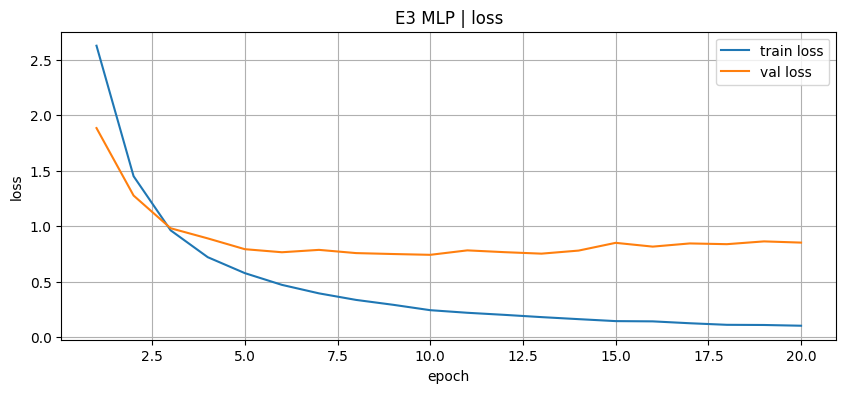

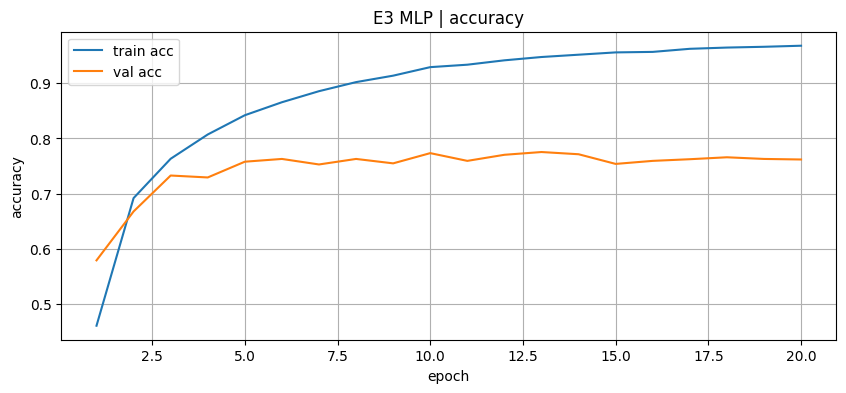

In [52]:
set_seed()
E3 = MLP(hidden_dims=(256, 64), dropout_p=0.0, use_batchnorm=True).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(E3.parameters(), lr=1e-3)

history_E3 = fit(
    E3, train_loader, val_loader,
    optimizer, criterion,
    epochs=20,
    early_stopping=None
)

plot_history(history_E3, title="E3 MLP")

In [53]:
max(history_E3['val_acc'])

0.7755

Epoch 01/20 | train loss 2.6246, acc 0.461 | val loss 1.8829, acc 0.580 | 7.2s
Epoch 02/20 | train loss 1.4493, acc 0.692 | val loss 1.2752, acc 0.668 | 8.2s
Epoch 03/20 | train loss 0.9616, acc 0.763 | val loss 0.9806, acc 0.733 | 8.2s
Epoch 04/20 | train loss 0.7200, acc 0.807 | val loss 0.8893, acc 0.730 | 8.1s
Epoch 05/20 | train loss 0.5765, acc 0.842 | val loss 0.7921, acc 0.758 | 8.1s
Epoch 06/20 | train loss 0.4707, acc 0.866 | val loss 0.7645, acc 0.763 | 8.4s
Epoch 07/20 | train loss 0.3942, acc 0.886 | val loss 0.7859, acc 0.753 | 8.2s
Epoch 08/20 | train loss 0.3352, acc 0.902 | val loss 0.7569, acc 0.763 | 8.5s
Epoch 09/20 | train loss 0.2912, acc 0.914 | val loss 0.7485, acc 0.755 | 8.4s
Epoch 10/20 | train loss 0.2427, acc 0.929 | val loss 0.7413, acc 0.773 | 8.1s
Epoch 11/20 | train loss 0.2194, acc 0.933 | val loss 0.7814, acc 0.759 | 7.5s
Epoch 12/20 | train loss 0.2006, acc 0.941 | val loss 0.7653, acc 0.770 | 7.0s
Epoch 13/20 | train loss 0.1803, acc 0.947 | val los

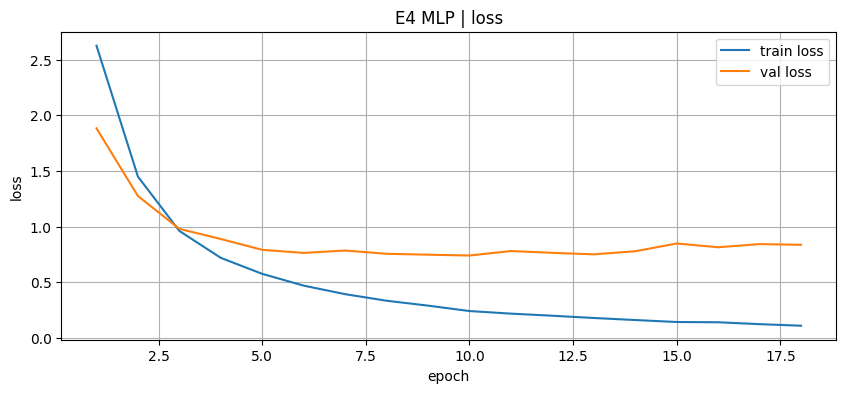

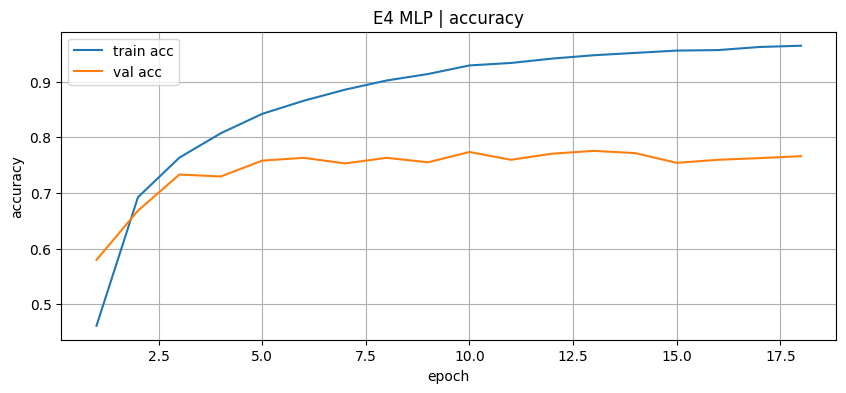

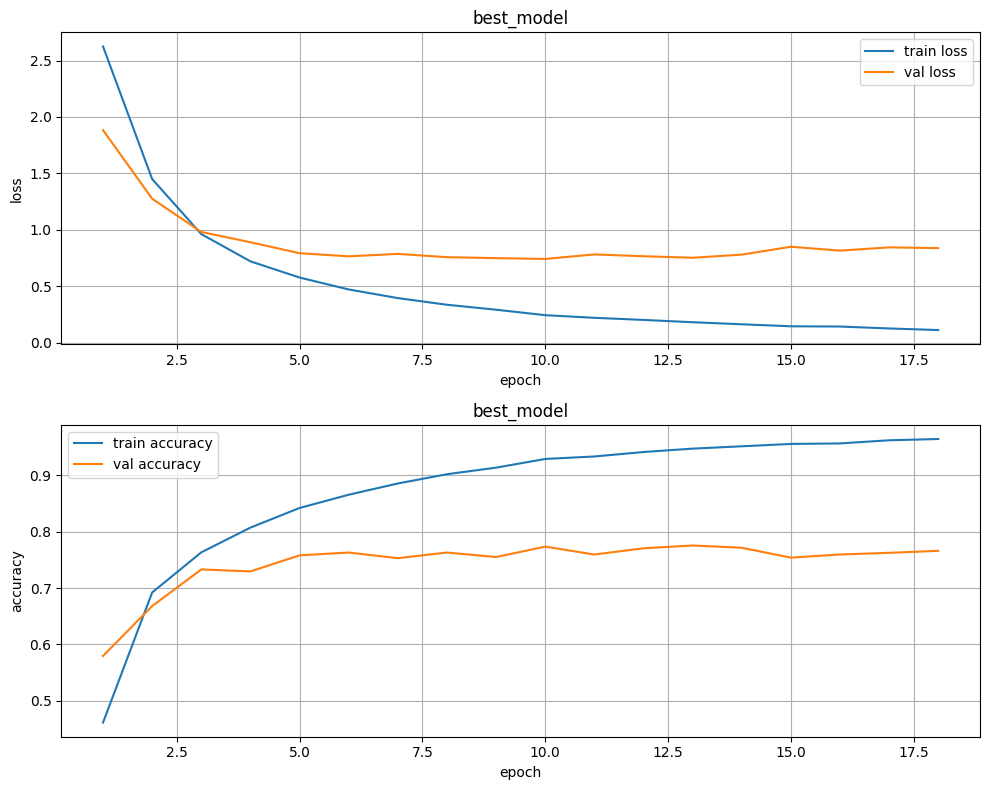

In [54]:
set_seed()

E4 = MLP(hidden_dims=(256, 64), dropout_p=0.0, use_batchnorm=True).to(DEVICE)
es = EarlyStopping(patience=5, min_delta=0.001)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(E4.parameters(), lr=1e-3)

history_E4 = fit(
    E4, train_loader, val_loader,
    optimizer, criterion,
    epochs=20,
    early_stopping=es
)

plot_history(history_E4, title="E4 MLP")

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
epochs = list(range(1, len(history_E4["train_loss"]) + 1))
plt.plot(epochs, history_E4["train_loss"], label="train loss")
plt.plot(epochs, history_E4["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("best_model")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
epochs = list(range(1, len(history_E4["train_acc"]) + 1))
plt.plot(epochs, history_E4["train_acc"], label="train accuracy")
plt.plot(epochs, history_E4["val_acc"], label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("best_model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/curves_best.png")
plt.show()

In [55]:
max_E1_val_acc=max(history_E1['val_acc'])
max_E2_val_acc=max(history_E2['val_acc'])
max_E3_val_acc=max(history_E3['val_acc'])
max_E4_val_acc=max(history_E4['val_acc'])
print('val_accuracy E1:', max_E1_val_acc)
print('val_accuracy E2:', max_E2_val_acc)
print('val_accuracy E3:', max_E3_val_acc)
print('val_accuracy E4:', max_E4_val_acc)

val_accuracy E1: 0.759
val_accuracy E2: 0.7735
val_accuracy E3: 0.7755
val_accuracy E4: 0.7755


In [56]:
test_loss, test_acc = evaluate(E4, test_loader, criterion)
print("accuracy на тесте:", test_acc)
print("loss на тесте:", test_loss)

accuracy на тесте: 0.7553333333333333
loss на тесте: 0.8297564655939738


In [57]:
torch.save(E4.state_dict(), 'artifacts/best_model.pt')

Epoch 01/6 | train loss 1.7426, acc 0.506 | val loss 1.4379, acc 0.558 | 7.2s
Epoch 02/6 | train loss 1.0595, acc 0.673 | val loss 1.1817, acc 0.644 | 7.3s
Epoch 03/6 | train loss 0.9223, acc 0.706 | val loss 1.0097, acc 0.680 | 8.2s
Epoch 04/6 | train loss 0.7797, acc 0.745 | val loss 1.0290, acc 0.690 | 7.8s
Epoch 05/6 | train loss 0.7058, acc 0.765 | val loss 1.0509, acc 0.686 | 8.1s
Epoch 06/6 | train loss 0.6594, acc 0.779 | val loss 1.0519, acc 0.701 | 8.2s


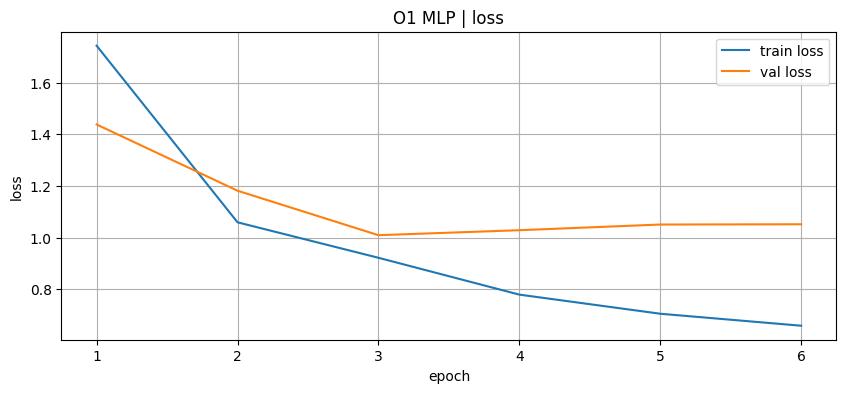

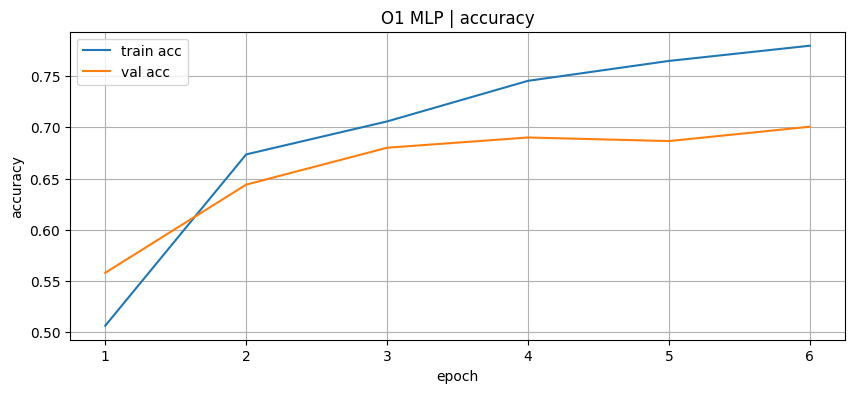

In [58]:
set_seed()

O1 = MLP(hidden_dims=(256, 64), dropout_p=0.0, use_batchnorm=True).to(DEVICE)
es = EarlyStopping(patience=5, min_delta=0.001)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(O1.parameters(), lr=1e-1)

history_O1 = fit(
    O1, train_loader, val_loader,
    optimizer, criterion,
    epochs=6,
    early_stopping=es
)

plot_history(history_O1, title="O1 MLP")

Epoch 01/6 | train loss 3.8781, acc 0.037 | val loss 3.8025, acc 0.060 | 8.3s
Epoch 02/6 | train loss 3.7491, acc 0.068 | val loss 3.6891, acc 0.094 | 8.4s
Epoch 03/6 | train loss 3.6382, acc 0.104 | val loss 3.5893, acc 0.138 | 8.2s
Epoch 04/6 | train loss 3.5446, acc 0.143 | val loss 3.5097, acc 0.173 | 8.4s
Epoch 05/6 | train loss 3.4631, acc 0.186 | val loss 3.4336, acc 0.205 | 8.0s
Epoch 06/6 | train loss 3.3917, acc 0.220 | val loss 3.3736, acc 0.234 | 8.3s


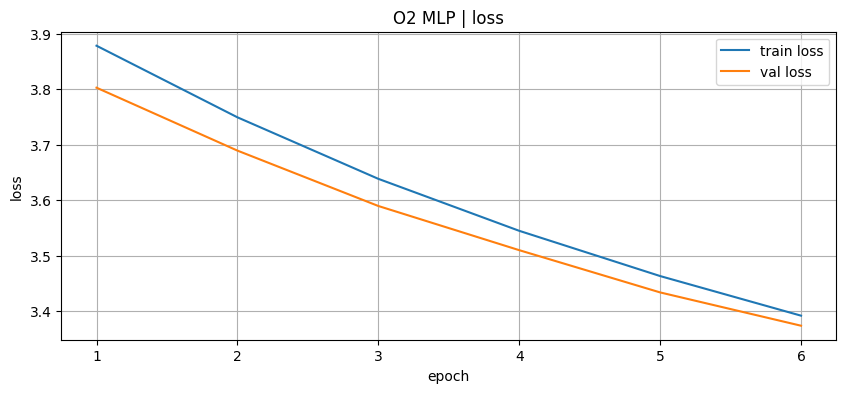

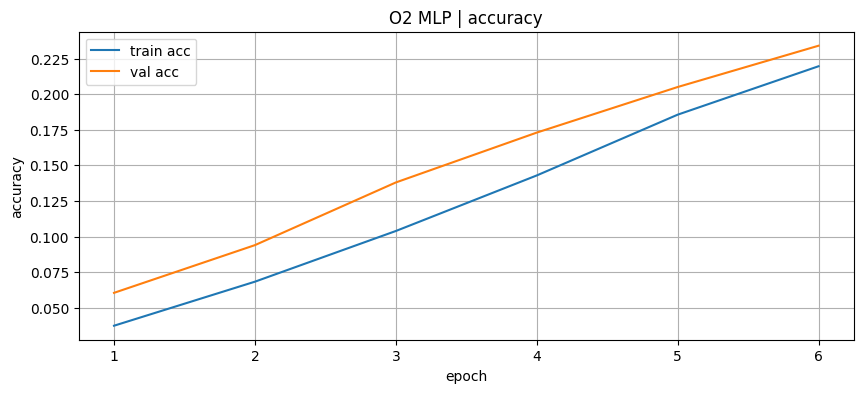

In [59]:
set_seed()

O2 = MLP(hidden_dims=(256, 64), dropout_p=0.0, use_batchnorm=True).to(DEVICE)
es = EarlyStopping(patience=5, min_delta=0.001)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(O2.parameters(), lr=1e-5)

history_O2 = fit(
    O2, train_loader, val_loader,
    optimizer, criterion,
    epochs=6,
    early_stopping=es
)

plot_history(history_O2, title="O2 MLP")

Epoch 01/15 | train loss 3.6125, acc 0.134 | val loss 3.3121, acc 0.252 | 8.2s
Epoch 02/15 | train loss 3.1544, acc 0.340 | val loss 3.0209, acc 0.402 | 8.3s
Epoch 03/15 | train loss 2.8870, acc 0.443 | val loss 2.7867, acc 0.461 | 8.1s
Epoch 04/15 | train loss 2.6621, acc 0.505 | val loss 2.5966, acc 0.509 | 8.2s
Epoch 05/15 | train loss 2.4562, acc 0.546 | val loss 2.4004, acc 0.535 | 8.1s
Epoch 06/15 | train loss 2.2665, acc 0.578 | val loss 2.2330, acc 0.560 | 8.1s
Epoch 07/15 | train loss 2.0934, acc 0.602 | val loss 2.0757, acc 0.580 | 8.1s
Epoch 08/15 | train loss 1.9336, acc 0.630 | val loss 1.9295, acc 0.599 | 8.0s
Epoch 09/15 | train loss 1.7890, acc 0.653 | val loss 1.8127, acc 0.617 | 7.9s
Epoch 10/15 | train loss 1.6580, acc 0.674 | val loss 1.6969, acc 0.633 | 7.0s
Epoch 11/15 | train loss 1.5399, acc 0.694 | val loss 1.5920, acc 0.650 | 7.5s
Epoch 12/15 | train loss 1.4331, acc 0.710 | val loss 1.5058, acc 0.658 | 8.1s
Epoch 13/15 | train loss 1.3378, acc 0.725 | val los

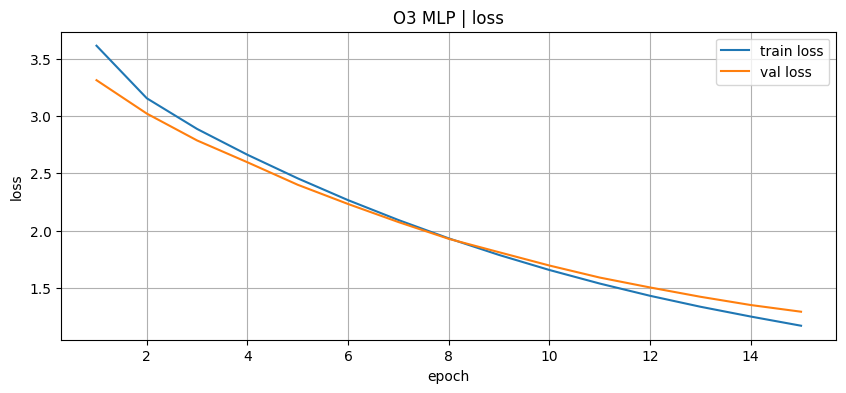

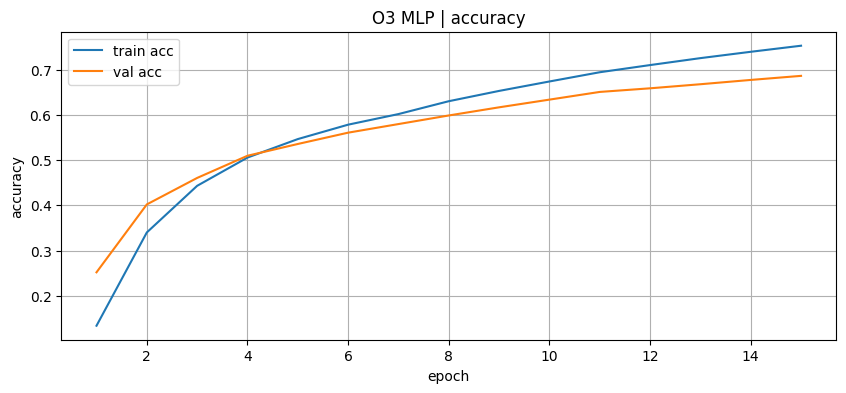

In [60]:
set_seed()

O3 = MLP(hidden_dims=(256, 64), dropout_p=0.0, use_batchnorm=True).to(DEVICE)
es = EarlyStopping(patience=5, min_delta=0.001)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(O3.parameters(), lr=1e-3, weight_decay=1e-4, momentum=0.9)

history_O3 = fit(
    O3, train_loader, val_loader,
    optimizer, criterion,
    epochs=15,
    early_stopping=es
)

plot_history(history_O3, title="O3 MLP")

In [61]:
runs = pd.DataFrame(columns=['experiment_id','dataset','seed','model_summary',
                             'optimizer','lr','momentum','weight_decay',
                             'epochs_trained','best_val_accuracy','best_val_loss'])
E1_df = {'experiment_id': 'E1',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'base',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'momentum': 0,
           'weight_decay': 0,
           'epochs_trained': 20,
           'best_val_accuracy': max(history_E1['val_acc']),
           'best_val_loss': min(history_E1['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E1_df])], ignore_index=True)

E2_df = {'experiment_id': 'E2',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'Dropout = 0.3',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'momentum': 0,
           'weight_decay': 0,
           'epochs_trained': 20,
           'best_val_accuracy': max(history_E2['val_acc']),
           'best_val_loss': min(history_E2['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E2_df])], ignore_index=True)

E3_df = {'experiment_id': 'E3',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'BatchNorm',
           'optimizer': 'Adam',
           'lr': 1e-3,
           'momentum': 0,
           'weight_decay': 0,
           'epochs_trained': 20,
           'best_val_accuracy': max(history_E3['val_acc']),
           'best_val_loss': min(history_E3['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E3_df])], ignore_index=True)

E4_df = {'experiment_id': 'E4',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'EarlyStopping + E3',
          'optimizer': 'Adam',
          'lr': 1e-3,
          'momentum': 0,
          'weight_decay': 0,
          'epochs_trained': len(history_E4['val_acc']),
          'best_val_accuracy': max(history_E4['val_acc']),
          'best_val_loss': min(history_E4['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E4_df])], ignore_index=True)

O1_df = {'experiment_id': 'O1',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'lr=1e-1 + E4',
           'optimizer': 'Adam',
           'lr': 0.01,
           'momentum': 0,
           'weight_decay': 0,
           'epochs_trained': 6,
           'best_val_accuracy': max(history_O1['val_acc']),
           'best_val_loss': min(history_O1['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([O1_df])], ignore_index=True)

O2_df = {'experiment_id': 'O2',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'lr=1e-5 + E4',
           'optimizer': 'Adam',
           'lr': 1e-5,
           'momentum': 0,
           'weight_decay': 0,
           'epochs_trained': 6,
           'best_val_accuracy': max(history_O2['val_acc']),
           'best_val_loss': min(history_O2['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([O2_df])], ignore_index=True)

O3_df = {'experiment_id': 'O3',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'SGD + weight_decay=1e-4, momentum=0.9',
           'optimizer': 'SGD',
           'lr': 1e-3,
           'momentum': 0.9,
           'weight_decay': 1e-4,
           'epochs_trained': 12,
           'best_val_accuracy': max(history_O3['val_acc']),
           'best_val_loss': min(history_O3['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([O3_df])], ignore_index=True)
runs.to_csv("artifacts/runs.csv")

In [62]:
import json
best_config = runs.iloc[3].to_dict()
best_config.pop('experiment_id')
best_config['net_layers'] = ['Flatten()',
                             'Linear()',
                             'BatchNorm()',
                             'ReLU()',
                             'Linear()',
                             'BatchNorm()',
                             'ReLU()',
                             'Linear()']
best_config['early_stopping_patience'] = 5
best_config['early_stopping_min_delta'] = 0.0001

print(best_config)

{'dataset': 'EMNIST', 'seed': 42, 'model_summary': 'EarlyStopping + E3', 'optimizer': 'Adam', 'lr': 0.001, 'momentum': 0, 'weight_decay': 0, 'epochs_trained': 18, 'best_val_accuracy': 0.7755, 'best_val_loss': 0.7412727847099304, 'net_layers': ['Flatten()', 'Linear()', 'BatchNorm()', 'ReLU()', 'Linear()', 'BatchNorm()', 'ReLU()', 'Linear()'], 'early_stopping_patience': 5, 'early_stopping_min_delta': 0.0001}


In [63]:
with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)

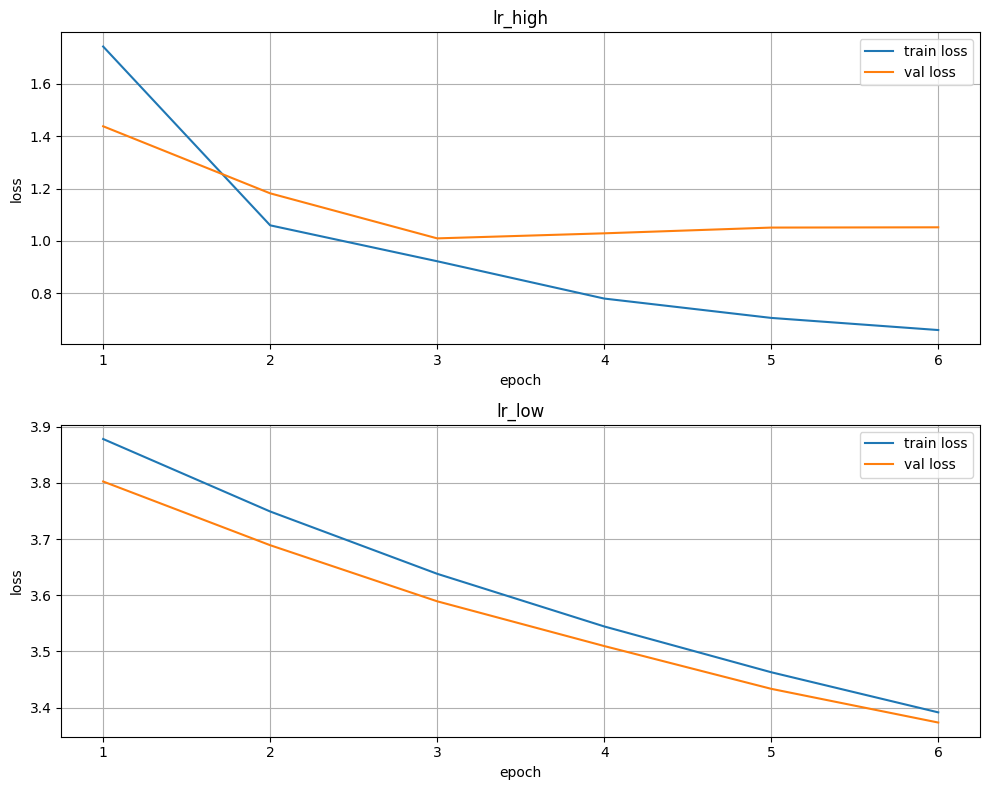

In [64]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
epochs = list(range(1, len(history_O1["train_loss"]) + 1))
plt.plot(epochs, history_O1["train_loss"], label="train loss")
plt.plot(epochs, history_O1["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("lr_high")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
epochs = list(range(1, len(history_O2["train_loss"]) + 1))
plt.plot(epochs, history_O2["train_loss"], label="train loss")
plt.plot(epochs, history_O2["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("lr_low")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()